# MachSense — 02. Benchmark End-to-End

Cross-domain validation of **MachSense** across standard benchmarks:
- **NASA C-MAPSS FD001** (Turbofan degradation with 21 sensors & 3 operational settings, true test set RUL comparison)
- **FEMTO / PRONOSTIA** (Accelerated bearing degradation benchmark under dynamic load)

Switch `BENCHMARK = 'cmapss'` or `'femto'` to train and evaluate on the respective dataset.

In [1]:
from pathlib import Path
import sys, shutil, json, numpy as np, pandas as pd, matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
print("Project root:", ROOT)

from src.validation import audit_table, assert_no_leakage, check_checkpoint
from src.experiment import train_machsense, load_checkpoint, predict_series
from src.data_pipeline import (
    require_free_space, download_file, safe_extract,
    build_femto_features, FEMTO_URL,
    download_cmapss_fd001, build_cmapss_fd001
)
from src.features import choose_numeric_features, condition_columns, standardize

# Benchmark configuration
BENCHMARK = "femto"  # 'cmapss' or 'femto'
EPOCHS = 25
WINDOW = 32
BATCH_SIZE = 64


Project root: C:\Users\rahul\Downloads\MachSense_Model_v4\MachSense_Model_v4


## 1. Download and prepare the selected benchmark
Download dataset files and construct standardized feature parquet tables.

In [2]:
if BENCHMARK == "femto":
    require_free_space(ROOT, 4.0)
    raw = ROOT / "data" / "raw" / "FEMTO"
    dl = ROOT / "data" / "downloads"
    proc = ROOT / "data" / "processed"
    raw.mkdir(parents=True, exist_ok=True)
    dl.mkdir(parents=True, exist_ok=True)
    proc.mkdir(parents=True, exist_ok=True)
    z = dl / "FEMTO_Bearing.zip"
    download_file(FEMTO_URL, z)
    root = safe_extract(z, raw)
    df = build_femto_features(root, proc / "femto_features.parquet")
    MODEL_NAME = "femto"
elif BENCHMARK == "cmapss":
    require_free_space(ROOT, 1.0)
    raw = ROOT / "data" / "raw" / "CMAPSS_FD001"
    proc = ROOT / "data" / "processed"
    raw.mkdir(parents=True, exist_ok=True)
    proc.mkdir(parents=True, exist_ok=True)
    download_cmapss_fd001(raw)
    train_df, test_df = build_cmapss_fd001(
        raw,
        proc / "cmapss_fd001_train.parquet",
        proc / "cmapss_fd001_test.parquet",
        proc / "cmapss_fd001_true_rul.csv"
    )
    df = train_df
    MODEL_NAME = "cmapss"
else:
    raise ValueError("BENCHMARK must be femto or cmapss")

print(f"{BENCHMARK.upper()} dataset loaded with shape: {df.shape}")


[skip] FEMTO_Bearing.zip (1.16 GB)
[skip] Using existing features from femto_features.parquet
FEMTO dataset loaded with shape: (7534, 8)


## 2. Quality and leakage checks
Audit numeric consistency and verify zero target/temporal leakage.

In [3]:
df = standardize(df)
print("Audit summary:", audit_table(df, BENCHMARK))
features = choose_numeric_features(df)
conditions = condition_columns(df, BENCHMARK)
assert_no_leakage(features)
print(f"Model input features ({len(features)}):", features)
print(f"Operating conditions ({len(conditions)}):", conditions)


Audit summary: {'name': 'femto', 'rows': 7534, 'runs': 6, 'columns': 8, 'missing_values': 0}
Model input features (2): ['h_rms', 'v_rms']
Operating conditions (2): ['speed', 'load']


## 3. Train MachSense
Train MachSense model on the benchmark training set.

In [4]:
checkpoint_path, metrics, sample_path = train_machsense(
    df, MODEL_NAME, epochs=EPOCHS, batch_size=BATCH_SIZE, window=WINDOW
)
print("Checkpoint:", checkpoint_path)
print("Held-out run:", metrics["validation_bearing"])
print("Best validation loss:", f"{metrics['best_val_loss']:.4f}")
print("Check CSV:", sample_path)


[femto] epoch=001 train=0.1438 val=0.0673 normalized_RMSE=0.1972
[femto] epoch=005 train=0.0882 val=0.0889 normalized_RMSE=0.2668
[femto] epoch=010 train=0.0827 val=0.1104 normalized_RMSE=0.2473
[femto] epoch=015 train=0.0819 val=0.1308 normalized_RMSE=0.2697
[femto] epoch=020 train=0.0820 val=0.1235 normalized_RMSE=0.2633
[femto] epoch=025 train=0.0819 val=0.1218 normalized_RMSE=0.2593
Checkpoint: C:\Users\rahul\Downloads\MachSense_Model_v4\MachSense_Model_v4\artifacts\checkpoints\machsense_femto.pt
Held-out run: Bearing3_2
Best validation loss: 0.0673
Check CSV: C:\Users\rahul\Downloads\MachSense_Model_v4\MachSense_Model_v4\artifacts\check_samples\femto_validation_input.csv


## 4. Held-out trajectory
Plot health trajectory, median RUL prediction, and anomaly scores for the held-out validation trajectory.

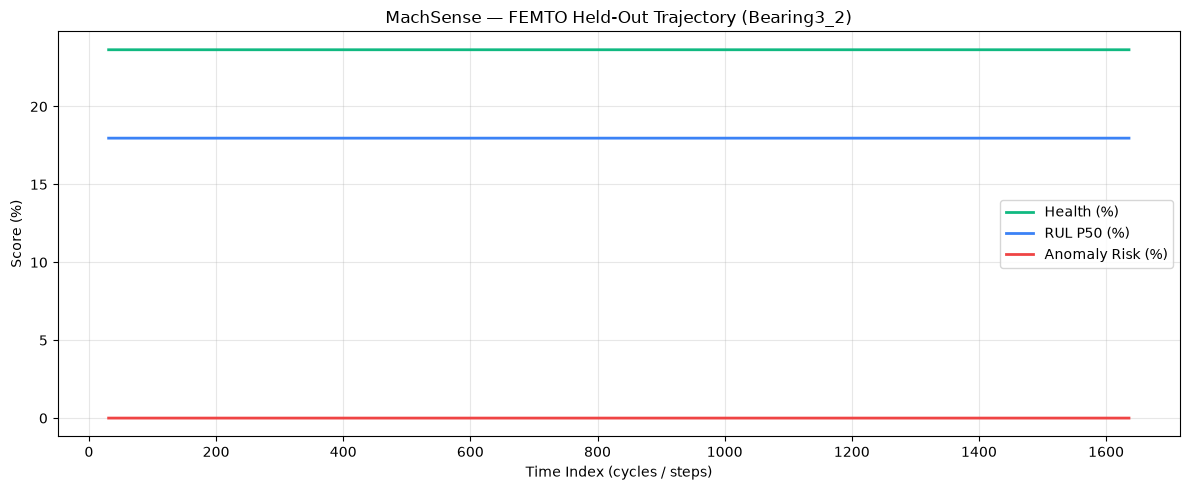

Last 10 observations:


,index,bearing_id,time_idx,health,rul_p10,rul_p50,rul_p90,anomaly,stage,action,rul_p50_native
1596,1627,Bearing3_2,1627,23.640302,6.601065,17.966582,75.55747,5.681710e-79,Wear-out,URGENT INSPECTION / PLAN SHUTDOWN,503.423615
1597,1628,Bearing3_2,1628,23.640302,6.601065,17.966582,75.55747,5.681710e-79,Wear-out,URGENT INSPECTION / PLAN SHUTDOWN,503.423615
1598,1629,Bearing3_2,1629,23.640302,6.601065,17.966582,75.55747,5.681710e-79,Wear-out,URGENT INSPECTION / PLAN SHUTDOWN,503.423615
1599,1630,Bearing3_2,1630,23.640302,6.601065,17.966582,75.55747,5.681710e-79,Wear-out,URGENT INSPECTION / PLAN SHUTDOWN,503.423615
1600,1631,Bearing3_2,1631,23.640302,6.601065,17.966582,75.55747,5.681710e-79,Wear-out,URGENT INSPECTION / PLAN SHUTDOWN,503.423615
1601,1632,Bearing3_2,1632,23.640302,6.601065,17.966582,75.55747,5.681710e-79,Wear-out,URGENT INSPECTION / PLAN SHUTDOWN,503.423615
1602,1633,Bearing3_2,1633,23.640302,6.601065,17.966582,75.55747,5.681710e-79,Wear-out,URGENT INSPECTION / PLAN SHUTDOWN,503.423615
1603,1634,Bearing3_2,1634,23.640302,6.601065,17.966582,75.55747,5.681710e-79,Wear-out,URGENT INSPECTION / PLAN SHUTDOWN,503.423615
1604,1635,Bearing3_2,1635,23.640302,6.601065,17.966582,75.55747,5.681710e-79,Wear-out,URGENT INSPECTION / PLAN SHUTDOWN,503.423615
1605,1636,Bearing3_2,1636,23.640302,6.601065,17.966582,75.55747,5.681710e-79,Wear-out,URGENT INSPECTION / PLAN SHUTDOWN,503.423615


In [5]:
_, ckpt = load_checkpoint(MODEL_NAME)
held = metrics["validation_bearing"]
val = df[df.bearing_id.astype(str) == str(held)].copy()
pred = predict_series(val, ckpt)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(pred.time_idx, pred.health, label="Health (%)", color="#10b981", linewidth=2)
ax.plot(pred.time_idx, pred.rul_p50, label="RUL P50 (%)", color="#3b82f6", linewidth=2)
ax.plot(pred.time_idx, pred.anomaly, label="Anomaly Risk (%)", color="#ef4444", linewidth=2)
ax.set_xlabel("Time Index (cycles / steps)")
ax.set_ylabel("Score (%)")
ax.set_title(f"MachSense — {BENCHMARK.upper()} Held-Out Trajectory ({held})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Last 10 observations:")
display(pred.tail(10))


## 5. C-MAPSS native test-set check (only for C-MAPSS)
Evaluate model predictions on all 100 actual C-MAPSS test engines against the ground truth RUL values.

In [6]:
if BENCHMARK == "cmapss":
    from src.model import MachSenseNet
    cfg = ckpt["config"]
    shared_model = MachSenseNet(
        len(ckpt["features"]), len(ckpt["condition_cols"]),
        hidden=cfg["hidden_dim"], layers=cfg["layers"],
        dropout=cfg["dropout"], cond_dim=cfg["condition_dim"]
    )
    shared_model.load_state_dict(ckpt["model_state"])
    shared_model.eval()

    rows = []
    for bid, g in test_df.groupby("bearing_id"):
        p = predict_series(g, ckpt, model=shared_model)
        if len(p):
            rows.append((bid, float(p.rul_p50_native.iloc[-1])))
    test_pred = pd.DataFrame(rows, columns=["bearing_id", "predicted_rul_cycles"])
    test_pred["unit"] = test_pred.bearing_id.str.replace("test_", "", regex=False).astype(int)
    truth = pd.read_csv(ROOT / "data/processed/cmapss_fd001_true_rul.csv").reset_index(drop=True)
    truth["unit"] = np.arange(1, len(truth) + 1)
    merged = test_pred.merge(truth, on="unit", how="left")
    merged["abs_error"] = (merged.predicted_rul_cycles - merged.rul).abs()
    print(f"Evaluated {len(test_pred)} test engines.")
    print(f"C-MAPSS test MAE (cycles): {merged.abs_error.mean():.2f}")
    display(merged.head(10))
else:
    print("FEMTO benchmark evaluated on held-out bearing run.")


FEMTO benchmark evaluated on held-out bearing run.


## 6. Final integrity check
Verify model checkpoint validity and serialization format.

In [7]:
check_checkpoint(checkpoint_path)
print(f"[OK] Benchmark notebook complete for: {BENCHMARK}")


[OK] Benchmark notebook complete for: femto
